In [6]:
import pandas as pd
data=pd.read_csv('Unitsold_cleaned (1).csv')
print(data)

          Customer Name    State     Product  Units Sold  Unit Price  \
0          Unknown Name   Rivers    Keyboard          48         NaN   
1          allison hill    Lagos  Headphones          48   267992.94   
2           noah rhodes  Anambra    Keyboard          48    42364.41   
3       angie henderson    Delta    Keyboard          48   279444.94   
4         daniel wagner    Delta      Tablet          48    95899.74   
..                  ...      ...         ...         ...         ...   
553        Unknown Name    Ekiti     Monitor           6    23989.09   
554  katherine martinez  Katsina      Others          48   223764.24   
555          jodi roach   Bauchi       Phone          48   104084.92   
556     brandon fleming    Niger     Charger          48    29756.89   
557        Unknown Name      Imo      Camera          48    70027.13   

    Total Sale   Sale Date Sales Channel                              Order ID  
0          NaN   4/27/2025        Online              

In [7]:
print(data['Unit Price'].isnull().sum())
print(data['Unit Price'].value_counts(dropna=False))

59
Unit Price
NaN          59
118189.90     2
139176.04     1
17758.37      1
124096.91     1
             ..
202483.14     1
88859.77      1
101465.10     1
4718.22       1
2545.62       1
Name: count, Length: 499, dtype: int64


In [8]:
print(data['Unit Price'].describe())

count    4.990000e+02
mean     1.760215e+05
std      3.329536e+05
min      1.403130e+03
25%      8.562906e+04
50%      1.586879e+05
75%      2.264303e+05
max      6.329990e+06
Name: Unit Price, dtype: float64


In [9]:
print(data['Unit Price'].dtype)
print(data['Unit Price'].head(10))
print(data['Unit Price'].describe())

float64
0          NaN
1    267992.94
2     42364.41
3    279444.94
4     95899.74
5    118189.90
6    185141.90
7    118189.90
8    252859.28
9    178320.53
Name: Unit Price, dtype: float64
count    4.990000e+02
mean     1.760215e+05
std      3.329536e+05
min      1.403130e+03
25%      8.562906e+04
50%      1.586879e+05
75%      2.264303e+05
max      6.329990e+06
Name: Unit Price, dtype: float64


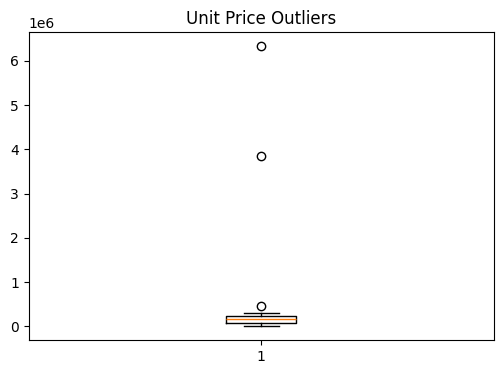

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(data['Unit Price'].dropna())
plt.title("Unit Price Outliers")
plt.show()

In [11]:
Q1=data['Unit Price'].quantile(0.25)
Q3=data['Unit Price'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
outliers=data[(data['Unit Price']<lower) | (data['Unit Price']>upper)]
print(outliers)

    Customer Name  State Product  Units Sold  Unit Price  Total Sale  \
103  Unknown Name  Abuja  Laptop          48   459478.11  05-02-2025   
104  Unknown Name  Lagos  Tablet          48  6329990.01  11-10-2023   
106  Unknown Name  Enugu  Tablet          48  3853718.91  01-12-2025   

     Sale Date                         Sales Channel Order ID  
103     Retail  317304b5-c1dd-484a-aca5-8d95915a1c30      NaN  
104  Wholesale  a383889a-db2c-4ac8-9c67-83932ced3c0d      NaN  
106     Direct                                   NaN      NaN  


In [16]:
med=data['Unit Price'].median()
data['Unit Price']=data['Unit Price'].fillna(med)
print(data['Unit Price'].value_counts(dropna=False))

Unit Price
158687.85     60
118189.90      2
43733.35       1
17758.37       1
124096.91      1
125244.11      1
159232.55      1
116831.51      1
76871.20       1
99413.77       1
24181.59       1
135211.15      1
111637.71      1
160922.84      1
248907.18      1
113461.81      1
139176.04      1
257333.60      1
67990.69       1
72669.97       1
161609.52      1
55571.75       1
90316.60       1
122773.62      1
209044.37      1
157576.69      1
114655.81      1
193173.16      1
103652.24      1
14541.79       1
203785.66      1
15935.22       1
216862.87      1
140068.22      1
264902.18      1
108213.56      1
92872.47       1
194792.04      1
140142.01      1
85276.23       1
96823.70       1
72179.62       1
119291.30      1
211278.69      1
208840.07      1
274375.17      1
166977.27      1
224190.33      1
222571.82      1
57412.10       1
63936.43       1
272743.75      1
91304.81       1
272156.33      1
63062.28       1
65496.45       1
201599.43      1
176481.31      1
241

In [24]:
data['Unit Price']=data['Unit Price'].replace(wrong_val,med)

In [25]:
wrong_val=[459478.11,6329990.01,3853718.91]
print(data[data['Unit Price'].isin(wrong_val)])



Empty DataFrame
Columns: [Customer Name, State, Product, Units Sold, Unit Price, Total Sale, Sale Date, Sales Channel, Order ID]
Index: []


In [28]:
print(data['Unit Price'].value_counts(dropna=False).to_string())

Unit Price
158687.85    63
118189.90     2
12344.49      1
181688.35     1
113461.81     1
15935.22      1
248907.18     1
160922.84     1
111637.71     1
135211.15     1
24181.59      1
99413.77      1
76871.20      1
116831.51     1
159232.55     1
125244.11     1
17758.37      1
139176.04     1
43733.35      1
257333.60     1
67990.69      1
72669.97      1
161609.52     1
55571.75      1
90316.60      1
122773.62     1
209044.37     1
157576.69     1
114655.81     1
193173.16     1
14541.79      1
124096.91     1
96409.87      1
216862.87     1
240943.58     1
140068.22     1
264902.18     1
108213.56     1
92872.47      1
194792.04     1
140142.01     1
85276.23      1
96823.70      1
72179.62      1
119291.30     1
211278.69     1
103652.24     1
274375.17     1
226422.06     1
224190.33     1
222571.82     1
57412.10      1
63936.43      1
272743.75     1
91304.81      1
272156.33     1
63062.28      1
65496.45      1
201599.43     1
176481.31     1
241492.86     1
22298.91     

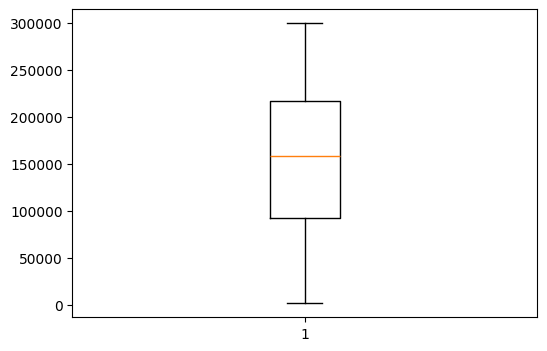

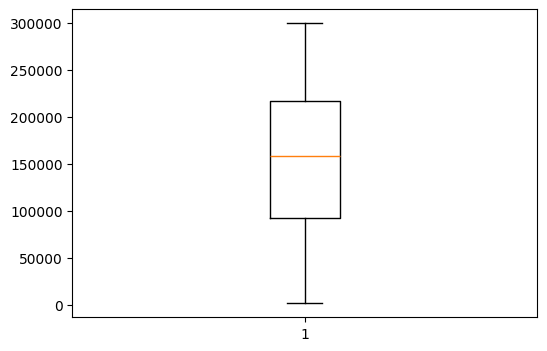

In [30]:
plt.figure(figsize=(6,4))
plt.boxplot(data['Unit Price'].dropna())
plt.show()

In [32]:
from google.colab import files
data.to_csv('Unit_price_cleaned.csv')
files.download('Unit_price_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>